In [47]:
import pandas as pd
import numpy as np

In [48]:
df= pd.read_csv('dataset/Results.csv')

In [49]:
df.head()

,Race,Year,Name,Gender,Age,Finish,Age Bracket
0,Columbus Marathon,2015,Becky Williams,F,29,13645,Under 35
1,Columbus Marathon,2015,Jessica Sheahan,F,27,13648,Under 35
2,Columbus Marathon,2015,Kelsey Stief,F,27,13650,Under 35
3,Columbus Marathon,2015,Mehgan Cline,F,26,13650,Under 35
4,Columbus Marathon,2015,Stefanie Driesenga,F,28,13652,Under 35


In [50]:
df.shape

(2053366, 7)

In [51]:
df.describe()

,Year,Age,Finish
count,2.053366e+06,2.053366e+06,2.053366e+06
mean,2.014416e+03,3.919313e+01,1.651780e+04
std,2.833053e+00,1.207902e+01,3.366605e+03
min,2.010000e+03,-9.000000e+00,7.425000e+03
25%,2.012000e+03,3.100000e+01,1.408000e+04
50%,2.014000e+03,3.900000e+01,1.613500e+04
75%,2.017000e+03,4.800000e+01,1.855300e+04
max,2.019000e+03,1.160000e+02,7.346000e+04


Check Duplicates

In [52]:
df.duplicated().sum()

np.int64(282)

In [53]:
df.drop_duplicates(inplace=True)

Standardize the data

In [54]:
df[df['Age']<0]

,Race,Year,Name,Gender,Age,Finish,Age Bracket
422,St. George Marathon,2012,UNKOWN RUNNER,M,-1,13821,Under 35
2200,RnR Las Vegas Marathon,2019,Vytautas Pukis,M,-1,12572,Under 35
2201,RnR Las Vegas Marathon,2019,Jordan Parfitt,M,-1,12590,Under 35
2202,RnR Las Vegas Marathon,2019,Krishna Akkaram,M,-1,12602,Under 35
2203,RnR Las Vegas Marathon,2019,Stephanie Kortan,F,-1,12610,Under 35
...,...,...,...,...,...,...,...
1573560,NYC Marathon,2016,Anonymous,NaN,-1,24979,Under 35
1577241,NYC Marathon,2016,Anonymous,NaN,-1,16654,Under 35
1585958,NYC Marathon,2016,Anonymous,NaN,-1,17330,Under 35
1607573,NYC Marathon,2011,Anonymous,NaN,-1,15484,Under 35


In [55]:
df[df['Age']<0]['Age Bracket'].isnull().sum()

np.int64(0)

In [56]:
df[df['Year']<0]


,Race,Year,Name,Gender,Age,Finish,Age Bracket


In [57]:
df[df['Finish']<0]

,Race,Year,Name,Gender,Age,Finish,Age Bracket


In [58]:
df['Gender'].value_counts()

Gender
M    1157592
F     895484
Name: count, dtype: int64

Check for Nan values

In [59]:
df.isna().sum()

Race           0
Year           0
Name           2
Gender         8
Age            0
Finish         0
Age Bracket    0
dtype: int64

In [60]:
#Since we have large datset dropping the missing val rows in gender and year is reasonable
df.dropna(subset=['Gender'], inplace=True)
df.dropna(subset=['Name'], inplace=True)

In [61]:
df.groupby('Race')['Name'].count().sort_values(ascending=False).head(10)

Race
NYC Marathon                        450228
Chicago Marathon                    401553
Marine Corps Marathon               211715
Philadelphia Marathon                97560
Twin Cities Marathon                 81767
St. George Marathon                  52275
Portland Marathon                    48888
Columbus Marathon                    43620
Richmond Marathon                    43333
Indianapolis Monumental Marathon     37516
Name: Name, dtype: int64

Exploratory Data Analysis

In [62]:
(df['Year'].value_counts(normalize=True)*100).round(2).sort_index()

Year
2010    10.08
2011    10.53
2012     8.71
2013    11.46
2014    10.93
2015    10.33
2016     9.82
2017     9.45
2018     9.34
2019     9.34
Name: proportion, dtype: float64

In [63]:
df.groupby('Year')['Finish'].min().sort_values()

Year
2013    7425
2014    7451
2012    7478
2011    7506
2018    7511
2019    7545
2010    7584
2016    7671
2017    7760
2015    7765
Name: Finish, dtype: int64

In [64]:
top10= df.sort_values(by='Finish', ascending=True).head(10)
top10

,Race,Year,Name,Gender,Age,Finish,Age Bracket
1092564,Chicago Marathon,2013,Dennis Kimetto,M,29,7425,Under 35
1092565,Chicago Marathon,2013,Emannuel Mutai,M,29,7432,Under 35
1230265,Chicago Marathon,2014,Eliud Kipchoge,M,29,7451,Under 35
1230266,Chicago Marathon,2014,Sammy Kitwara,M,29,7468,Under 35
1230267,Chicago Marathon,2014,Dickson Chumba,M,29,7472,Under 35
949317,Chicago Marathon,2012,Tsegaye Kebede,M,29,7478,Under 35
949318,Chicago Marathon,2012,Feyisa Lilesa,M,24,7492,Under 35
1601396,NYC Marathon,2011,Geoffrey Mutai,M,30,7506,Under 35
1036440,Chicago Marathon,2018,Mo Farah,M,39,7511,35-39
1092566,Chicago Marathon,2013,Sammy Kitwara,M,29,7516,Under 35


In [65]:
top10['Age'].mean()

np.float64(29.6)

In [66]:
top10f= df[df['Gender']=='F'].sort_values(by='Finish', ascending=True).head(10)
top10f

,Race,Year,Name,Gender,Age,Finish,Age Bracket
1260164,Chicago Marathon,2019,Brigid Kosgei,F,29,8044,Under 35
924525,Chicago Marathon,2017,Tirunesh Dibaba,F,34,8311,Under 35
1031440,Chicago Marathon,2018,Brigid Kosgei,F,24,8315,Under 35
1123956,Chicago Marathon,2013,Rita Jeptoo,F,34,8397,Under 35
924526,Chicago Marathon,2017,Brigid Kosgei,F,24,8422,Under 35
1123957,Chicago Marathon,2013,Jemima Sumgong Jelegat,F,29,8448,Under 35
1260165,Chicago Marathon,2019,Ababel Yeshaneh,F,29,8451,Under 35
1260166,Chicago Marathon,2019,Gelete Burka,F,34,8455,Under 35
924527,Chicago Marathon,2017,Jordan Hasay,F,29,8457,Under 35
1031441,Chicago Marathon,2018,Roza Dereje,F,24,8478,Under 35


In [67]:
top10f['Age'].mean()

np.float64(29.0)

In [68]:
top10f.iloc[0]['Finish']-top10.iloc[0]['Finish']

np.int64(619)

In [69]:
fastestM= df[df['Gender']=='M'].groupby('Race')['Finish'].min()
fastestF= df[df['Gender']=='F'].groupby('Race')['Finish'].min()
fastest= pd.concat([fastestM, fastestF], axis=1, keys=['M', 'F'])
fastest['Difference'] = fastest['F'] - fastest['M']
fastest.sort_values(by='Difference', ascending=True).head(10)

,M,F,Difference
Race,,,
Nike Womens Marathon,10346,10002,-344
Marshall University Marathon,9393,9614,221
Mo Cowbell Marathon,9712,10067,355
Towpath Marathon,9803,10340,537
Chicago Marathon,7425,8044,619
Freedom's Run,9883,10519,636
Omaha Marathon,9229,10000,771
Maui Marathon,9813,10656,843
Baystate Marathon,8631,9540,909


In [70]:
df[df['Race']=='Nike Womens Marathon'].value_counts(subset=['Gender'])

Gender
F         16790
M          1565
Name: count, dtype: int64

In [71]:
yearlyM= df[df['Gender']=='M'].groupby('Year')['Finish'].min()
yearlyF= df[df['Gender']=='F'].groupby('Year')['Finish'].min()
yearly= pd.concat([yearlyM, yearlyF], axis=1, keys=['M', 'F'])
yearly.sort_values(by='Year', ascending=False)

,M,F
Year,,
2019,7545,8044
2018,7511,8315
2017,7760,8311
2016,7671,8492
2015,7765,8613
2014,7451,8707
2013,7425,8397
2012,7478,8523
2011,7506,8529


In [72]:
df.groupby('Age Bracket')['Finish'].mean().round(2).sort_values(ascending=False)

Age Bracket
80 and Over    22188.39
75-79          21891.46
70-74          20371.93
65-69          19119.43
60-64          18131.53
55-59          17412.86
50-54          16861.91
45-49          16553.40
40-44          16353.39
35-39          16252.59
Under 35       16242.86
Name: Finish, dtype: float64

In [75]:
from numpy import median

df['Age Bracket']= pd.Categorical(df['Age Bracket'], categories=['Under 35', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 and Over'], ordered=True)
pt= pd.pivot_table(df, values='Finish', index='Age Bracket', columns='Year', aggfunc=median, fill_value=0)
pt

Year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
Age Bracket,,,,,,,,,,
Under 35,15965.0,16016.0,15874.0,15848.0,15914.0,16088.0,16027.0,16108.0,15872.0,15731.0
35-39,15838.0,15853.0,15755.0,15743.0,15853.0,16034.5,16051.0,16156.0,15864.0,15713.0
40-44,15760.0,15801.5,15770.0,15739.0,15972.0,16196.0,16223.5,16337.0,15994.0,15848.0
45-49,15869.0,15963.0,15884.5,15882.0,16078.0,16274.5,16340.0,16589.5,16269.0,16184.5
50-54,16282.5,16348.0,16214.0,16149.0,16341.0,16552.0,16602.0,16766.0,16605.0,16457.0
55-59,17036.0,17135.0,16865.0,16793.5,16929.0,17096.5,17057.0,17232.0,17015.0,16861.0
60-64,17762.5,17823.5,17489.5,17627.0,17768.5,17735.5,17855.0,17982.0,17689.0,17533.0
65-69,18962.0,18933.5,18990.0,18543.0,18789.5,18897.5,18908.0,19089.0,18815.0,18685.5
70-74,20121.5,20050.5,19823.0,20012.0,20424.0,20452.5,20738.0,20452.0,20067.5,19791.0


Text(0.5, 1.0, 'Median Finish Time by Age Bracket and Year')

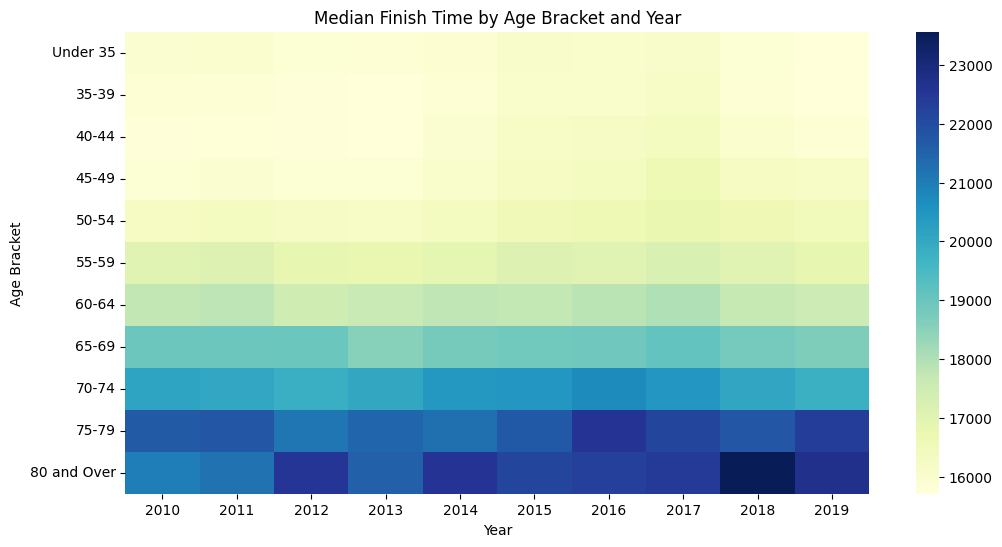

In [76]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(pt, annot=False, fmt='.0f', cmap='YlGnBu')
plt.title('Median Finish Time by Age Bracket and Year')